In [42]:
import pandas as pd

Perth_Cycling_df = pd.read_csv('Perth_Cycling_df.csv')
df = Perth_Cycling_df.copy()  # Create a copy of the cycling-station subsample for further analysis
print(f"Loaded Perth_Cycling_df: {len(df)} rows")
df.head()

Loaded Perth_Cycling_df: 4745 rows


,PUBLISH_DATE,TRADING_NAME,BRAND_DESCRIPTION,PRODUCT_DESCRIPTION,PRODUCT_PRICE,ADDRESS,LOCATION,POSTCODE,AREA_DESCRIPTION,REGION_DESCRIPTION,TGP_Perth,margin,delta_price
0,2022-01-01,Ampol Foodary East Perth,Ampol,ULP,173.9,157 Lord St,PERTH,6000,North of River,Metro,148.1,25.8,NaN
1,2022-01-02,Ampol Foodary East Perth,Ampol,ULP,170.9,157 Lord St,PERTH,6000,North of River,Metro,148.1,22.8,-3.0
2,2022-01-03,Ampol Foodary East Perth,Ampol,ULP,167.9,157 Lord St,PERTH,6000,North of River,Metro,149.2,18.7,-3.0
3,2022-01-04,Ampol Foodary East Perth,Ampol,ULP,164.9,157 Lord St,PERTH,6000,North of River,Metro,149.4,15.5,-3.0
4,2022-01-05,Ampol Foodary East Perth,Ampol,ULP,161.9,157 Lord St,PERTH,6000,North of River,Metro,150.0,11.9,-3.0


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Parse date column and sort for station-level time ordering
df['PUBLISH_DATE'] = pd.to_datetime(df['PUBLISH_DATE'])
df = df.sort_values(['TRADING_NAME', 'PUBLISH_DATE']).reset_index(drop=True)

# 2. Create event indicator: E_t = 1 if date is June 1st or later, 0 otherwise
event_date = pd.Timestamp('2022-06-01')
df['event_indicator'] = (df['PUBLISH_DATE'] >= event_date).astype(int)

print(f"Event date: {event_date}")
print(f"Number of records with event_indicator=1: {(df['event_indicator'] == 1).sum()}")
print(f"Number of records with event_indicator=0: {(df['event_indicator'] == 0).sum()}")

# 3. Identify major brands (top 5 most frequent)
brand_counts = df['BRAND_DESCRIPTION'].value_counts()
major_brands = brand_counts.head(5).index.tolist()
print(f"\nMajor brands (top 5): {major_brands}")

# 4. Create major brand indicator: 1 if brand is in top 5, 0 otherwise
df['major_brand_indicator'] = df['BRAND_DESCRIPTION'].isin(major_brands).astype(int)

print(f"\nMajor brand indicator created")
print(f"  Records with major brand: {(df['major_brand_indicator'] == 1).sum()}")
print(f"  Records with other brands: {(df['major_brand_indicator'] == 0).sum()}")

# 5. Create pooled station-level delta retail price and position variables
# delta_retail_price = today's retail price minus yesterday's retail price for the same station
# position = yesterday's retail price minus today's TGP

df['yesterday_price'] = df.groupby('TRADING_NAME')['PRODUCT_PRICE'].shift(1)
df['delta_retail_price'] = df.groupby('TRADING_NAME')['PRODUCT_PRICE'].diff()
df['position'] = df['yesterday_price'] - df['TGP_Perth']

print(f"\nDelta retail price and position created")
print(f"  Non-missing delta_retail_price: {df['delta_retail_price'].notna().sum()}")
print(f"  Non-missing position: {df['position'].notna().sum()}")

# 6. Display summary statistics
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumns related to TVTP specification:")
print(f"  - event_indicator: {df['event_indicator'].unique()}")
print(f"  - major_brand_indicator: {df['major_brand_indicator'].unique()}")

# 7. Preview the data with new variables
print(f"\nSample of pooled station-level variables:")
print(df[['TRADING_NAME', 'PUBLISH_DATE', 'PRODUCT_PRICE', 'yesterday_price', 'delta_retail_price', 'position', 'TGP_Perth', 'major_brand_indicator']].head(10))

Event date: 2022-06-01 00:00:00
Number of records with event_indicator=1: 2782
Number of records with event_indicator=0: 1963

Major brands (top 5): ['Ampol', 'BP', 'Coles Express', 'Vibe', 'Puma']

Major brand indicator created
  Records with major brand: 4380
  Records with other brands: 365

Delta retail price and position created
  Non-missing delta_retail_price: 4732
  Non-missing position: 4732

DataFrame shape: (4745, 18)

Columns related to TVTP specification:
  - event_indicator: [0 1]
  - major_brand_indicator: [1 0]

Sample of pooled station-level variables:
               TRADING_NAME PUBLISH_DATE  PRODUCT_PRICE  yesterday_price  \
0  Ampol Foodary East Perth   2022-01-01          173.9              NaN   
1  Ampol Foodary East Perth   2022-01-02          170.9            173.9   
2  Ampol Foodary East Perth   2022-01-03          167.9            170.9   
3  Ampol Foodary East Perth   2022-01-04          164.9            167.9   
4  Ampol Foodary East Perth   2022-01-05    

In [58]:
# ============================================================================
# Step 3: Prepare exog_tvtp matrix with Position, Ramp, Major, and Interactions
# ============================================================================
# 
# Specification (Multinomial Logit form):
#   P(S_t = j | S_{t-1} = i, Z_t) = exp(Z_t' γ_ij) / Σ_k exp(Z_t' γ_ik)
#
# where Z_t = [1, position_t, ramp_t, major_t, ramp_t × major_t]
#   - position_t = yesterday price - today's TGP
#   - ramp_t = 0 if t < June 1st; = (t - June 1st).days if t >= June 1st
#   - major_t = 1 if major brand, 0 otherwise
#   - ramp_t × major_t captures how the effect of ramp differs for major brands

from statsmodels.tools.tools import add_constant

# Keep pooled station-level observations that define the endogenous variable
pooled_df = df.dropna(subset=['delta_retail_price', 'position']).copy()
pooled_df = pooled_df.sort_values(['PUBLISH_DATE', 'TRADING_NAME']).reset_index(drop=True)

# Create ramp variable: days since June 1st (0 before June 1st)
base_date = pd.Timestamp('2022-06-01')
pooled_df['ramp_variable'] = ((pooled_df['PUBLISH_DATE'] - base_date).dt.days).clip(lower=0)

# Create interaction terms
pooled_df['ramp_x_major'] = pooled_df['ramp_variable'] * pooled_df['major_brand_indicator']

# Build exog_tvtp matrix: constant + position + ramp + major + ramp×major
exog_tvtp = add_constant(
    pooled_df[['position', 'ramp_variable', 'major_brand_indicator', 'ramp_x_major']], 
    prepend=True
)
exog_tvtp.columns = ['const', 'position_t', 'ramp_t', 'major_t', 'ramp_t_x_major']

print("=" * 70)
print("EXOGENOUS VARIABLES FOR TIME-VARYING TRANSITION PROBABILITIES")
print("=" * 70)
print(f"\nPooled observation count: {len(pooled_df)}")
print(f"Exog_TVTP specification (Multinomial Logit form):")
print(f"  Z_t = [1 (constant), position_t, ramp_t, major_t, ramp_t × major_t]")
print(f"\nWhere:")
print(f"  position_t = yesterday price - today's TGP")
print(f"  ramp_t = 0 if PUBLISH_DATE < 2022-06-01")
print(f"  ramp_t = (PUBLISH_DATE - 2022-06-01).days if PUBLISH_DATE >= 2022-06-01")
print(f"  major_t = 1 if major brand, 0 otherwise")
print(f"  ramp_t × major_t = ramp effect modulation by brand type")
print(f"\nExog_TVTP shape: {exog_tvtp.shape}")
print(f"Exog_TVTP columns: {list(exog_tvtp.columns)}")
print(f"\nDate range: {pooled_df['PUBLISH_DATE'].min()} to {pooled_df['PUBLISH_DATE'].max()}")

# Display sample of exog_tvtp
print(f"\nFirst 10 rows of exog_tvtp:")
print(exog_tvtp.head(10))

print(f"\nRows around event date (2022-06-01):")
event_idx = pooled_df[pooled_df['PUBLISH_DATE'] == pd.Timestamp('2022-06-01')].index[0]
print(exog_tvtp.iloc[max(0, event_idx-3):min(len(exog_tvtp), event_idx+5)])

print(f"\nRamp variable statistics:")
print(f"  Min: {pooled_df['ramp_variable'].min()}")
print(f"  Max: {pooled_df['ramp_variable'].max()}")
print(f"  Mean (post-event): {pooled_df[pooled_df['ramp_variable'] > 0]['ramp_variable'].mean():.1f}")

print(f"\nMajor brand distribution in exog_tvtp:")
print(f"  Share with major_t=1: {pooled_df['major_brand_indicator'].mean():.4f}")
print(f"  Share with major_t=0: {(1 - pooled_df['major_brand_indicator'].mean()):.4f}")

EXOGENOUS VARIABLES FOR TIME-VARYING TRANSITION PROBABILITIES

Pooled observation count: 4732
Exog_TVTP specification (Multinomial Logit form):
  Z_t = [1 (constant), position_t, ramp_t, major_t, ramp_t × major_t]

Where:
  position_t = yesterday price - today's TGP
  ramp_t = 0 if PUBLISH_DATE < 2022-06-01
  ramp_t = (PUBLISH_DATE - 2022-06-01).days if PUBLISH_DATE >= 2022-06-01
  major_t = 1 if major brand, 0 otherwise
  ramp_t × major_t = ramp effect modulation by brand type

Exog_TVTP shape: (4732, 5)
Exog_TVTP columns: ['const', 'position_t', 'ramp_t', 'major_t', 'ramp_t_x_major']

Date range: 2022-01-02 00:00:00 to 2022-12-31 00:00:00

First 10 rows of exog_tvtp:
   const  position_t  ramp_t  major_t  ramp_t_x_major
0    1.0        25.8       0        1               0
1    1.0        25.8       0        1               0
2    1.0        25.8       0        1               0
3    1.0        25.8       0        1               0
4    1.0        25.8       0        1               

In [59]:
# ============================================================================
# Step 4: Prepare endogenous variable and fit pooled TVTP Markov Switching Model
# ============================================================================

# Pooled station-level endogenous variable: delta retail price
endog = pooled_df['delta_retail_price'].values

# Mean-equation exogenous regressors: position, major brand indicator, and interaction
pooled_df['position_x_major'] = pooled_df['position'] * pooled_df['major_brand_indicator']
exog_mean = pooled_df[['position', 'major_brand_indicator', 'position_x_major']]

print("=" * 70)
print("ENDOGENOUS VARIABLE PREPARATION")
print("=" * 70)
print(f"\nPooled station-level data shape: {pooled_df.shape}")
print(f"Endogenous variable (delta_retail_price) shape: {endog.shape}")
print(f"Exogenous mean-equation variables shape: {exog_mean.shape}")
print(f"Date range matches exog_tvtp: {len(endog) == len(exog_tvtp)}")

# Display summary
print(f"\nDelta retail price statistics:")
print(f"  Mean: {pooled_df['delta_retail_price'].mean():.4f}")
print(f"  Median: {pooled_df['delta_retail_price'].median():.4f}")
print(f"  Std: {pooled_df['delta_retail_price'].std():.4f}")
print(f"  Min: {pooled_df['delta_retail_price'].min():.4f}")
print(f"  Max: {pooled_df['delta_retail_price'].max():.4f}")

print(f"\nMean-equation covariate statistics:")
print(f"  position mean: {pooled_df['position'].mean():.4f}")
print(f"  major brand share: {pooled_df['major_brand_indicator'].mean():.4f}")
print(f"  position x major mean: {pooled_df['position_x_major'].mean():.4f}")

print(f"\nSample of pooled station-level data:")
print(pooled_df[['TRADING_NAME', 'PUBLISH_DATE', 'PRODUCT_PRICE', 'yesterday_price', 'delta_retail_price', 'position', 'major_brand_indicator', 'position_x_major', 'ramp_variable']].head(10))

# ============================================================================
# Step 5: Fit TVTP Markov Regime-Switching Model
# ============================================================================

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

print("\n" + "=" * 70)
print("FITTING POOLED TIME-VARYING TRANSITION PROBABILITY MARKOV MODEL")
print("=" * 70)

# Model specification:
# - 2 regimes
# - Endogenous variable: delta retail price
# - Mean-equation exogenous regressors: position + major + position*major
# - Exogenous TVTP: constant + position + ramp + ramp-position interaction

try:
    model_tvtp = MarkovRegression(
        endog=endog,
        k_regimes=2,
        trend='c',
        exog=exog_mean,
        exog_tvtp=exog_tvtp,
        switching_trend=True,
        switching_exog=True,
        switching_variance=True
    )
    
    print("\nModel initialized successfully!")
    print(f"  Number of regimes: {model_tvtp.k_regimes}")
    print(f"  Pooled station-level observations: {len(endog)}")
    print(f"  Mean-equation exogenous variables: {exog_mean.shape[1]}")
    print(f"  TVTP exogenous variables: {exog_tvtp.shape[1]}")
    print(f"  Mean equation: c + position + Major + position * Major")
    print(f"  TVTP specification: constant + position + ramp + ramp-position interaction")
    
    print("\nFitting model via Maximum Likelihood Estimation...")
    results_tvtp = model_tvtp.fit(disp=False, method='powell', maxiter=20, em_iter=5, search_reps=0)
    
    print("\n✓ Model fitted successfully!")
    print(f"\nFitted model summary:")
    print(f"  Log-likelihood: {results_tvtp.llf:.2f}")
    print(f"  AIC: {results_tvtp.aic:.2f}")
    print(f"  BIC: {results_tvtp.bic:.2f}")
    
except Exception as e:
    print(f"\n✗ Error fitting model: {str(e)}")
    import traceback
    traceback.print_exc()

ENDOGENOUS VARIABLE PREPARATION

Pooled station-level data shape: (4732, 21)
Endogenous variable (delta_retail_price) shape: (4732,)
Exogenous mean-equation variables shape: (4732, 3)
Date range matches exog_tvtp: True

Delta retail price statistics:
  Mean: -0.0157
  Median: -2.0000
  Std: 11.2762
  Min: -40.0000
  Max: 47.0000

Mean-equation covariate statistics:
  position mean: 12.4633
  major brand share: 0.9231
  position x major mean: 11.9029

Sample of pooled station-level data:
                       TRADING_NAME PUBLISH_DATE  PRODUCT_PRICE  \
0          Ampol Foodary East Perth   2022-01-02          170.9   
1         Ampol Foodary Leederville   2022-01-02          170.9   
2             Ampol Foodary Subiaco   2022-01-02          170.9   
3             BP Connect East Perth   2022-01-02          173.9   
4            BP Connect North Perth   2022-01-02          173.9   
5                       BP Highgate   2022-01-02          173.9   
6                  Puma North Perth   2

In [60]:
# ============================================================================
# Step 6: Extract and Analyze Regime-Switching Results
# ============================================================================

print("=" * 70)
print("REGIME-SPECIFIC PARAMETERS")
print("=" * 70)

params = results_tvtp.params
print(f"\nModel parameters ({len(params)} total):")
print(results_tvtp.summary())

print("\n" + "=" * 70)
print("SMOOTHED MARGINAL PROBABILITIES")
print("=" * 70)

smoothed_probs = results_tvtp.smoothed_marginal_probabilities
filtered_probs = results_tvtp.filtered_marginal_probabilities

print(f"\nSmoothed probabilities shape: {smoothed_probs.shape}")
print(f"  Rows (pooled observations): {smoothed_probs.shape[0]}")
print(f"  Columns (regimes): {smoothed_probs.shape[1]}")

dominant_regime = smoothed_probs.argmax(axis=1)
print(f"\nDominant regime over pooled observations:")
for regime in range(2):
    n_periods = (dominant_regime == regime).sum()
    pct = 100 * n_periods / len(dominant_regime)
    print(f"  Regime {regime}: {n_periods} observations ({pct:.1f}%)")

pooled_results_df = pooled_df[['PUBLISH_DATE', 'TRADING_NAME', 'BRAND_DESCRIPTION', 'PRODUCT_PRICE', 'TGP_Perth',
                               'delta_retail_price', 'position', 'major_brand_indicator', 'position_x_major', 'ramp_variable']].copy()
pooled_results_df['regime_prob_0'] = smoothed_probs[:, 0]
pooled_results_df['regime_prob_1'] = smoothed_probs[:, 1]
pooled_results_df['dominant_regime'] = dominant_regime

# Daily summary for visualization readability
plot_df = pooled_results_df.groupby('PUBLISH_DATE').agg({
    'delta_retail_price': 'mean',
    'position': 'mean',
    'regime_prob_0': 'mean',
    'regime_prob_1': 'mean',
    'ramp_variable': 'mean'
}).reset_index()
plot_df['dominant_regime'] = plot_df[['regime_prob_0', 'regime_prob_1']].values.argmax(axis=1)

print(f"\nSample of pooled regime classification (first 15 observations):")
print(pooled_results_df.head(15))

print(f"\nSample of pooled regime classification around event date 2022-06-01:")
event_row = pooled_results_df[pooled_results_df['PUBLISH_DATE'] == pd.Timestamp('2022-06-01')].index[0]
print(pooled_results_df.iloc[max(0, event_row-3):min(len(pooled_results_df), event_row+8)])

print("\n" + "=" * 70)
print("REGIME TRANSITION MATRIX (Estimated)")
print("=" * 70)

try:
    trans_matrix = results_tvtp.regime_transition_matrix
    print(f"\nTransition matrix shape: {trans_matrix.shape}")
    print(f"\nTransition probabilities (P[i,j] = Prob(S_t=j | S_t-1=i)):")
    trans_df = pd.DataFrame(
        trans_matrix.T,
        index=['To Regime 0', 'To Regime 1'],
        columns=['From Regime 0', 'From Regime 1']
    )
    print(trans_df.round(4))
except Exception as e:
    print(f"Note: Could not extract average transition matrix: {str(e)}")
    print("(This is expected with TVTP models as transition probabilities vary over time)")

print("\n" + "=" * 70)
print("TIME-VARYING TRANSITION PROBABILITIES")
print("=" * 70)

print(f"\nTransition probabilities are time-varying due to exog_tvtp specification")
print(f"Key structural break: event occurs on 2022-06-01")
print(f"  Before: Ramp = 0")
print(f"  After:  Ramp increases daily and interacts with major-brand indicator")

print(f"\nExog_TVTP around event date (2022-06-01):")
event_idx = pooled_df[pooled_df['PUBLISH_DATE'] == pd.Timestamp('2022-06-01')].index[0]
print(exog_tvtp.iloc[max(0, event_idx-3):min(len(exog_tvtp), event_idx+5)])

REGIME-SPECIFIC PARAMETERS

Model parameters (20 total):
                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                 4732
Model:               MarkovRegression   Log Likelihood              -13544.350
Date:                Fri, 19 Jun 2026   AIC                          27128.699
Time:                        17:50:42   BIC                          27257.941
Sample:                             0   HQIC                         27174.123
                               - 4732                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4851      0.198     -7.506      0.000      -1.873      -1

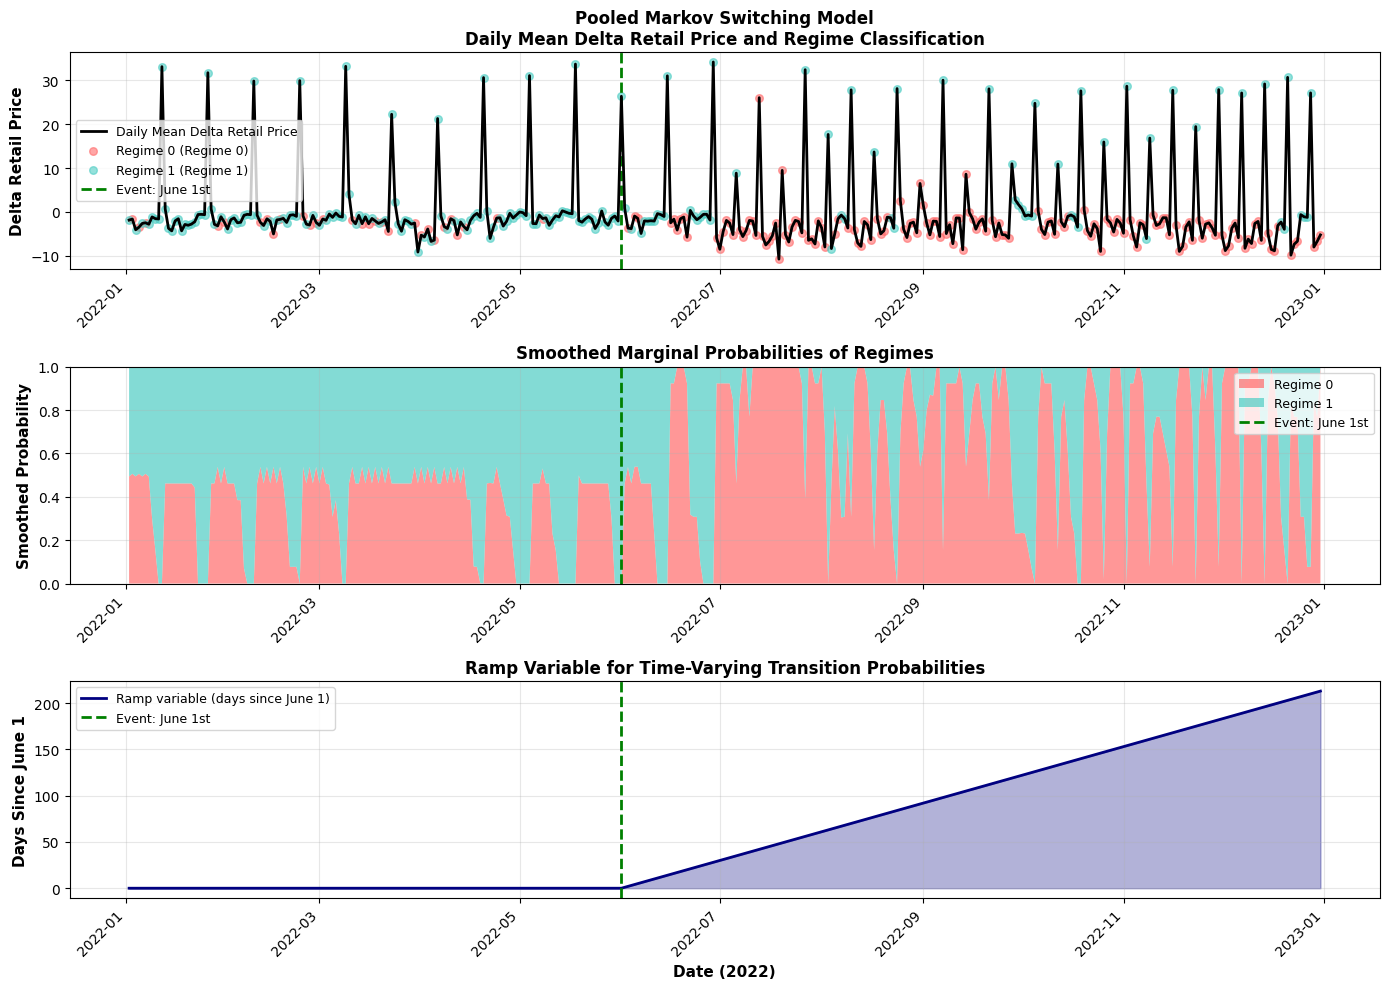

✓ Visualization saved as 'tvtp_markov_regime_analysis_ramp_pooled_2regimes.png'

INTERPRETATION OF TIME-VARYING TRANSITION PROBABILITY MODEL
POOLED STATION-LEVEL DELTA RETAIL PRICE SPECIFICATION

1. REGIME IDENTIFICATION (2-State Model):
   Regime 0: lower-change / more responsive state
   Regime 1: higher-change / more persistent state

2. REGIME DURATION:
   Regime 0: 2591 observations ( 54.8% of pooled sample)
   Regime 1: 2141 observations ( 45.2% of pooled sample)

3. EVENT IMPACT (June 1st) AND RAMP ACTIVATION:
   Pre-event (Jan 1 - May 31): Ramp = 0
      - Transition probabilities depend only on constant terms
   Post-event (Jun 1 - Dec 31): Ramp increases daily
      - Transition probabilities evolve linearly with time
      - Major-brand interaction allows differential transition responses

4. MEAN EQUATION INTERPRETATION:
   Endogenous variable: delta_retail_price
   Mean equation includes: position + major_brand_indicator + position*major_brand_indicator
   This captures st

In [47]:
# ============================================================================
# Step 7: Visualize Regime Dynamics and Time-Varying Transition Probabilities
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Daily mean delta retail price with regime shading
ax1 = axes[0]
ax1.plot(plot_df['PUBLISH_DATE'], plot_df['delta_retail_price'], 
         color='black', linewidth=2, label='Daily Mean Delta Retail Price', zorder=3)

for regime in range(2):
    regime_mask = plot_df['dominant_regime'] == regime
    regime_dates = plot_df[regime_mask]['PUBLISH_DATE'].values
    regime_values = plot_df[regime_mask]['delta_retail_price'].values
    colors = ['#FF6B6B', '#4ECDC4']
    regime_names = ['Regime 0', 'Regime 1']
    ax1.scatter(regime_dates, regime_values, c=colors[regime], s=30,
                alpha=0.6, label=f'Regime {regime} ({regime_names[regime]})')

ax1.axvline(pd.Timestamp('2022-06-01'), color='green', linestyle='--',
            linewidth=2, label='Event: June 1st', zorder=2)
ax1.set_ylabel('Delta Retail Price', fontsize=11, fontweight='bold')
ax1.set_title('Pooled Markov Switching Model\nDaily Mean Delta Retail Price and Regime Classification',
              fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Smoothed regime probabilities (stacked area)
ax2 = axes[1]
ax2.stackplot(plot_df['PUBLISH_DATE'],
              plot_df['regime_prob_0'],
              plot_df['regime_prob_1'],
              labels=['Regime 0', 'Regime 1'],
              colors=['#FF6B6B', '#4ECDC4'],
              alpha=0.7)

ax2.axvline(pd.Timestamp('2022-06-01'), color='green', linestyle='--',
            linewidth=2, label='Event: June 1st', zorder=2)
ax2.set_ylabel('Smoothed Probability', fontsize=11, fontweight='bold')
ax2.set_title('Smoothed Marginal Probabilities of Regimes',
              fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Ramp variable over time
ax3 = axes[2]
ax3.plot(plot_df['PUBLISH_DATE'], plot_df['ramp_variable'],
         color='navy', linewidth=2, label='Ramp variable (days since June 1)')
ax3.fill_between(plot_df['PUBLISH_DATE'], 0, plot_df['ramp_variable'],
                 alpha=0.3, color='navy')
ax3.axvline(pd.Timestamp('2022-06-01'), color='green', linestyle='--',
            linewidth=2, label='Event: June 1st', zorder=2)
ax3.set_xlabel('Date (2022)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Days Since June 1', fontsize=11, fontweight='bold')
ax3.set_title('Ramp Variable for Time-Varying Transition Probabilities',
              fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left', fontsize=9)

for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('tvtp_markov_regime_analysis_ramp_pooled_2regimes.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'tvtp_markov_regime_analysis_ramp_pooled_2regimes.png'")

# ============================================================================
# Summary Statistics and Interpretation
# ============================================================================

print("\n" + "=" * 70)
print("INTERPRETATION OF TIME-VARYING TRANSITION PROBABILITY MODEL")
print("POOLED STATION-LEVEL DELTA RETAIL PRICE SPECIFICATION")
print("=" * 70)

print(f"\n1. REGIME IDENTIFICATION (2-State Model):")
print(f"   Regime 0: lower-change / more responsive state")
print(f"   Regime 1: higher-change / more persistent state")

print(f"\n2. REGIME DURATION:")
for regime in range(2):
    n_periods = (dominant_regime == regime).sum()
    pct = 100 * n_periods / len(dominant_regime)
    print(f"   Regime {regime}: {n_periods:3d} observations ({pct:5.1f}% of pooled sample)")

print(f"\n3. EVENT IMPACT (June 1st) AND RAMP ACTIVATION:")
print(f"   Pre-event (Jan 1 - May 31): Ramp = 0")
print(f"      - Transition probabilities depend only on constant terms")
print(f"   Post-event (Jun 1 - Dec 31): Ramp increases daily")
print(f"      - Transition probabilities evolve linearly with time")
print(f"      - Major-brand interaction allows differential transition responses")

print(f"\n4. MEAN EQUATION INTERPRETATION:")
print(f"   Endogenous variable: delta_retail_price")
print(f"   Mean equation includes: position + major_brand_indicator + position*major_brand_indicator")
print(f"   This captures station-specific pricing adjustment relative to terminal gate price")

print("\n" + "=" * 70)

In [ ]:
3. RAMP VARIABLE:
   - Grows linearly from event date (June 1, 2022)
   - Captures time-dependent structural changes post-event
   - Allows transition probabilities to evolve dynamically

4. BRAND MODULATION IN TVTP:
   - Major brand indicator enters the TVTP exogenous variables
   - Ramp × Major interaction captures differential transition response
   - Major vs. non-major brands may have different regime-switching speeds post-event

5. MEAN EQUATION BRAND EFFECTS:
   - Major brand indicator and position interaction enter the mean equation
   - Major brands may have different delta-price responses to position


TIME-VARYING TRANSITION PROBABILITY MARKOV SWITCHING MODEL
FORMAL SPECIFICATION

1. MEAN EQUATION (2-regime specification)

   y_it = mu_{S_it} + beta_1 * position_it + beta_2 * Major_it + beta_3 * position_it * Major_it + epsilon_it,
   epsilon_it ~ N(0, 1)

Where:
   y_it        = Delta retail price for station i at time t
   S_it        in {0, 1}  regime state at observation (i,t)
   position_it = yesterday retail price - today's TGP
   Major_it    = 1 if station i is a major brand, 0 otherwise

   Regime interpretations:
   - Regime 0: lower-change / more responsive state
   - Regime 1: higher-change / more persistent state


2. TIME-VARYING TRANSITION PROBABILITY (Multinomial Logit Form)

   P(S_it = j | S_i,t-1 = i, Z_it) = exp(Z_it' * gamma_ij) / Sum_k exp(Z_it' * gamma_ik)

Where:
   gamma_ij  = Transition parameters from regime i to regime j
   Z_it      = Exogenous variable vector (dimension: 4 x 1):
               Z_it = [1, position_it, ramp_t, ramp_t * position_it]'

   r